In [2]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-fly')
print(tokenizer.pad_token_id)
print(tokenizer.eos_token_id)
print(tokenizer.bos_token_id)
print(tokenizer.cls_token_id)
print(tokenizer.mask_token_id)
print(tokenizer.sep_token_id)
print(tokenizer.unk_token_id)

3
None
None
1
4
2
0


In [3]:
import pandas as pd

df = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/predict/token_shuffle_analysis.csv')
df = df[~df['original_token'].isin([1,2])]


In [4]:
df['original_token'].unique()

array([   -1,   128,   329,  9319,    18,  2066,  3804, 14173,    24])

In [5]:
print(df[df['new_token'] == 0]['pred_change'].abs().mean())
df[df['new_token'] == 0]

0.005763456225395151


,position,original_token,new_token,prediction,label,is_original,pred_change
32000,1,128,0,1.055396,0.901654,False,0.005167
63999,2,329,0,1.053032,0.901654,False,0.002803
95998,3,9319,0,1.047374,0.901654,False,-0.002855
127997,4,18,0,1.059252,0.901654,False,0.009023
191995,6,2066,0,1.065968,0.901654,False,0.015739
223994,7,3804,0,1.048207,0.901654,False,-0.002022
255993,8,14173,0,1.056651,0.901654,False,0.006422
287992,9,24,0,1.052306,0.901654,False,0.002077


In [6]:
print(df[df['new_token'] == 4]['pred_change'].abs().mean())
df[(df['new_token'] == 4) | (df['position'] == -1)]

0.004991039633750876


,position,original_token,new_token,prediction,label,is_original,pred_change
0,-1,-1,-1,1.050229,0.901654,True,NaN
32004,1,128,4,1.053308,0.901654,False,0.003079
64003,2,329,4,1.052528,0.901654,False,0.002299
96002,3,9319,4,1.044910,0.901654,False,-0.005319
128001,4,18,4,1.055554,0.901654,False,0.005324
191999,6,2066,4,1.061535,0.901654,False,0.011306
223998,7,3804,4,1.040375,0.901654,False,-0.009854
255997,8,14173,4,1.052045,0.901654,False,0.001816
287996,9,24,4,1.049298,0.901654,False,-0.000931


In [7]:
import os
import sys
os.chdir('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency')
sys.path.append('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/scripts')
from GenaLMWithExtraFeatures import GenaLMWithExtraFeatures
model = GenaLMWithExtraFeatures.from_pretrained('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/ftModel/best_spearmanr')

allTokenEmbeddings = model.model.embeddings.word_embeddings.weight.detach()

/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/scripts/GenaLMWithExtraFeatures.py:156: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


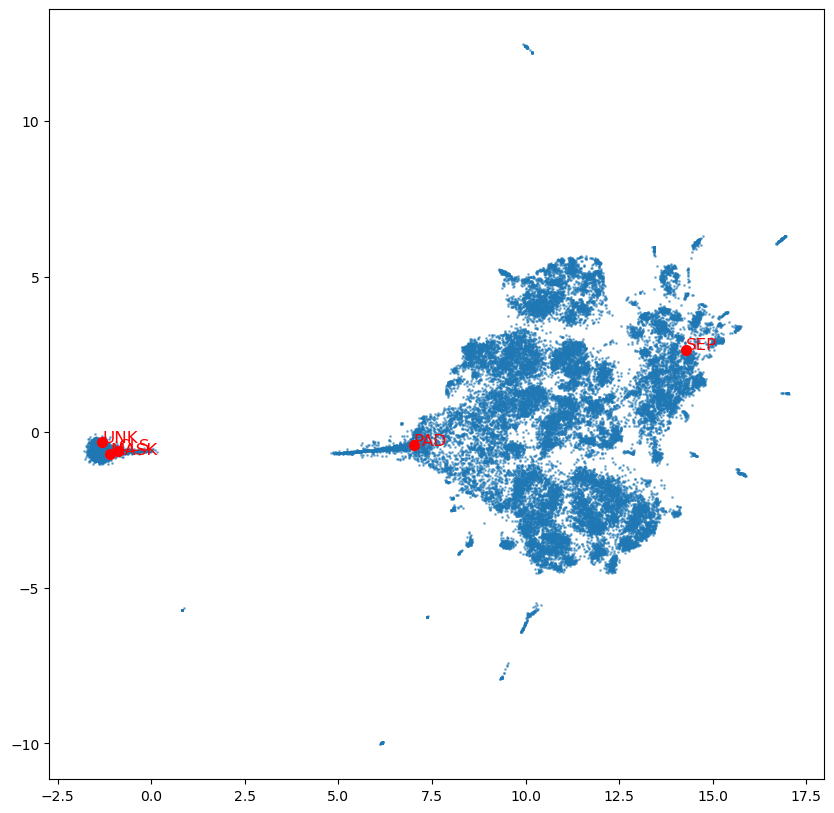

In [8]:
import umap

import matplotlib.pyplot as plt

embeddings = allTokenEmbeddings.cpu().numpy()
reducer = umap.UMAP()
embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=1, alpha=0.5)

special_ids = [0, 1, 2, 3, 4]
special_labels = ['UNK', 'CLS', 'SEP', 'PAD', 'MASK']
for i, label in zip(special_ids, special_labels):
    plt.scatter(embedding_2d[i, 0], embedding_2d[i, 1], color='red', s=50)
    plt.annotate(label, (embedding_2d[i, 0], embedding_2d[i, 1]), fontsize=12, color='red')

plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


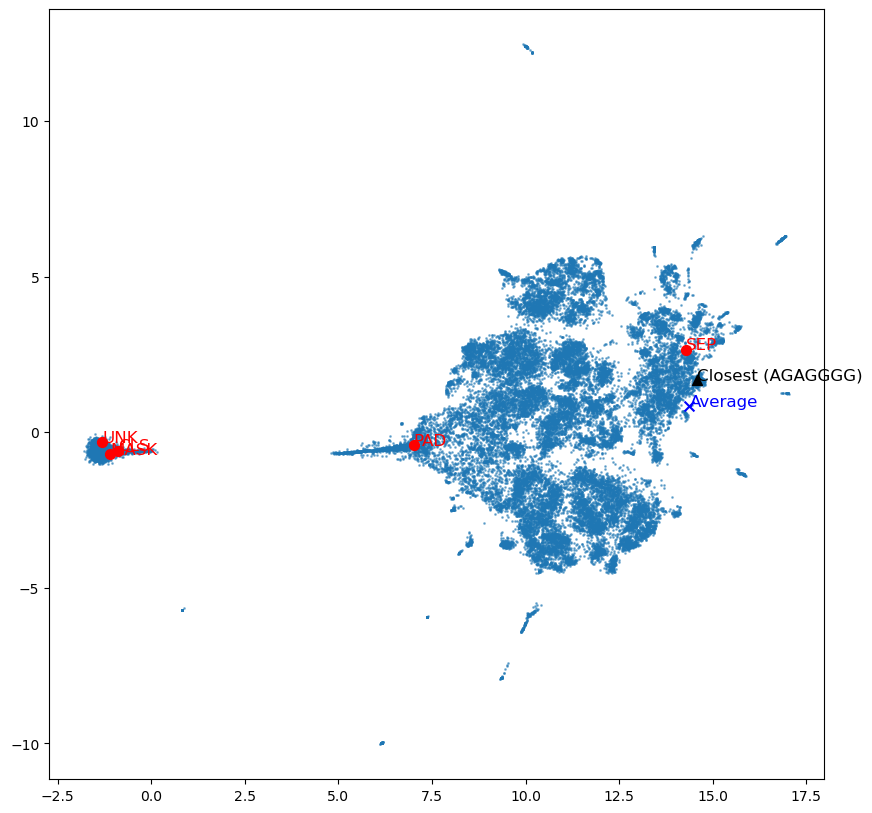

In [9]:
import numpy as np

# Compute the average embedding
average_embedding = np.mean(embeddings, axis=0)

# Project the average to 2D
average_2d = reducer.transform([average_embedding])

# Find the token closest to the average (Euclidean distance)
distances = np.linalg.norm(embeddings - average_embedding, axis=1)
closest_idx = int(np.argmin(distances))
closest_token = tokenizer.convert_ids_to_tokens(closest_idx)

plt.figure(figsize=(10, 10))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=1, alpha=0.5)
special_ids = [0, 1, 2, 3, 4]
special_labels = ['UNK', 'CLS', 'SEP', 'PAD', 'MASK']
for i, label in zip(special_ids, special_labels):
    plt.scatter(embedding_2d[i, 0], embedding_2d[i, 1], color='red', s=50)
    plt.annotate(label, (embedding_2d[i, 0], embedding_2d[i, 1]), fontsize=12, color='red')
# Add annotations to the plot (assuming the plot from cell 6 is still active)
plt.scatter(average_2d[0, 0], average_2d[0, 1], color='blue', s=50, marker='x')
plt.annotate('Average', (average_2d[0, 0], average_2d[0, 1]), fontsize=12, color='blue')

plt.scatter(embedding_2d[closest_idx, 0], embedding_2d[closest_idx, 1], color='black', s=50, marker='^')
plt.annotate(f'Closest ({closest_token})', (embedding_2d[closest_idx, 0], embedding_2d[closest_idx, 1]), fontsize=12, color='black')

plt.show()

In [10]:
from Bio import SeqIO

file_path = '/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/flyUTRs/train.fasta'

sequences = [str(record.seq) for record in SeqIO.parse(file_path, 'fasta')]

all_tokens = set()
for seq in sequences:
        utr5, utr3 = seq.split(',')
        utr5 = tokenizer.encode(str(utr5).replace('U',"T"), add_special_tokens=False)
        utr3 = tokenizer.encode(str(utr3).replace('U',"T"), add_special_tokens=False)
        all_tokens.update(utr5)
        all_tokens.update(utr3)




In [11]:
len(all_tokens)

28141

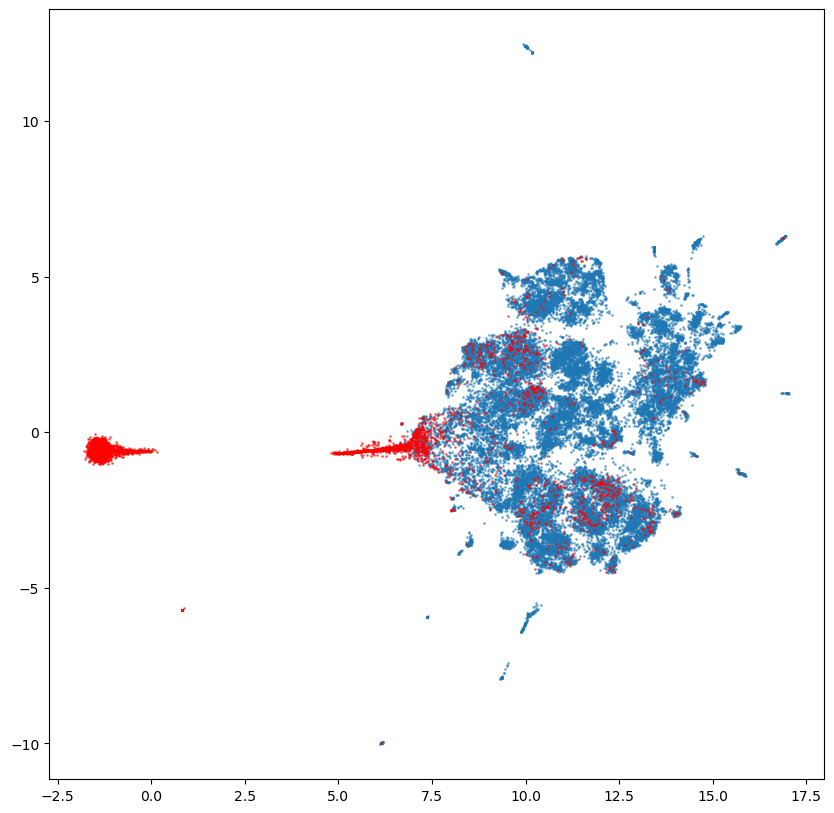

In [12]:
import numpy as np

plt.figure(figsize=(10, 10))
mask = np.array([i in all_tokens for i in range(len(embedding_2d))])
plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], s=1, alpha=0.5)
plt.scatter(embedding_2d[~mask, 0], embedding_2d[~mask, 1], s=1, alpha=0.5, color= 'red')

plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


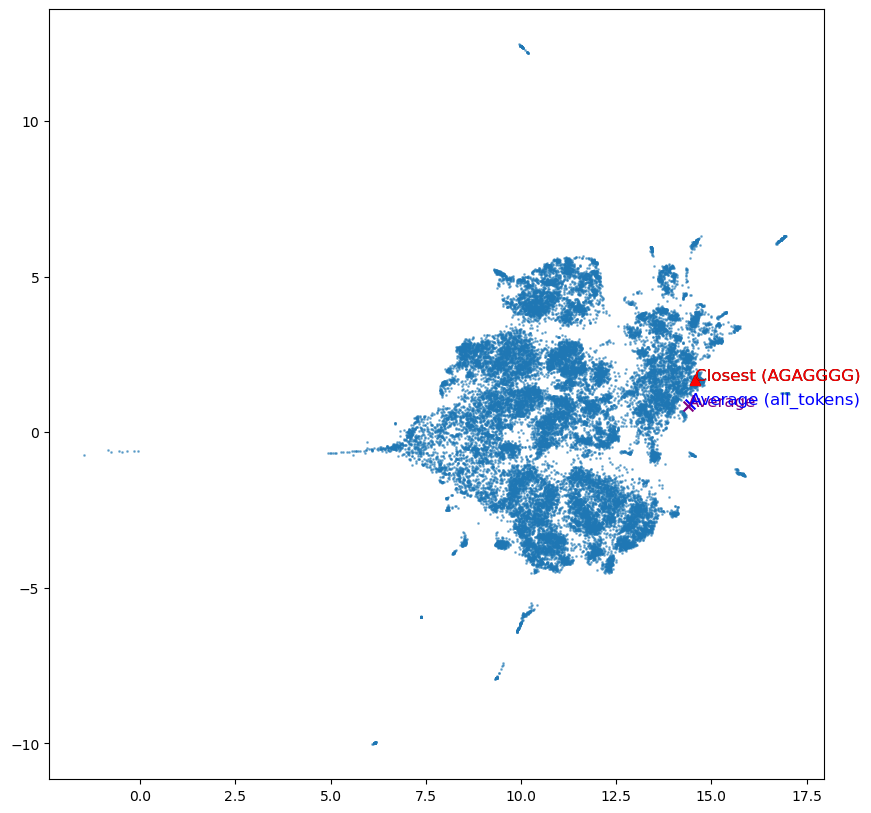

AGAGGGG
AGAGGGG


In [13]:
import numpy as np

# Compute the average embedding for the all_tokens subset
average_embedding_subset = np.mean(embeddings[list(all_tokens)], axis=0)

# Project the average to 2D
average_2d_subset = reducer.transform([average_embedding_subset])
# Find the token closest to the average (Euclidean distance)
distances = np.linalg.norm(embeddings - average_embedding_subset, axis=1)
closest_idx_subset = int(np.argmin(distances))
closest_token_subset = tokenizer.convert_ids_to_tokens(closest_idx_subset)

# Plot the existing scatter plot
plt.figure(figsize=(10, 10))
mask = np.array([i in all_tokens for i in range(len(embedding_2d))])
plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], s=1, alpha=0.5)
#plt.scatter(embedding_2d[~mask, 0], embedding_2d[~mask, 1], s=1, alpha=0.5, color='red')

# Add the average point
plt.scatter(average_2d_subset[0, 0], average_2d_subset[0, 1], color='blue', s=50, marker='x')
plt.annotate('Average', (average_2d[0, 0], average_2d[0, 1]), fontsize=12, color='purple')
plt.scatter(average_2d[0, 0], average_2d[0, 1], color='purple', s=50, marker='x')
plt.annotate('Average (all_tokens)', (average_2d_subset[0, 0], average_2d_subset[0, 1]), fontsize=12, color='blue')
plt.scatter(embedding_2d[closest_idx, 0], embedding_2d[closest_idx, 1], color='black', s=50, marker='^')
plt.annotate(f'Closest ({closest_token})', (embedding_2d[closest_idx, 0], embedding_2d[closest_idx, 1]), fontsize=12, color='black')
plt.scatter(embedding_2d[closest_idx_subset, 0], embedding_2d[closest_idx_subset, 1], color='red', s=50, marker='^')
plt.annotate(f'Closest ({closest_token_subset})', (embedding_2d[closest_idx_subset, 0], embedding_2d[closest_idx_subset, 1]), fontsize=12, color='red')

plt.show()
print(closest_token_subset)
print(closest_token)

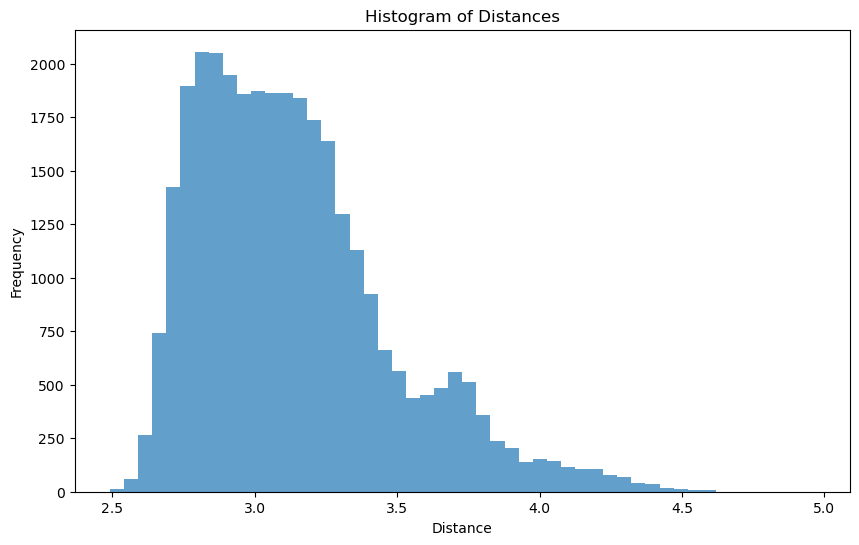

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(distances, bins=50, alpha=0.7)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Distances')
plt.show()

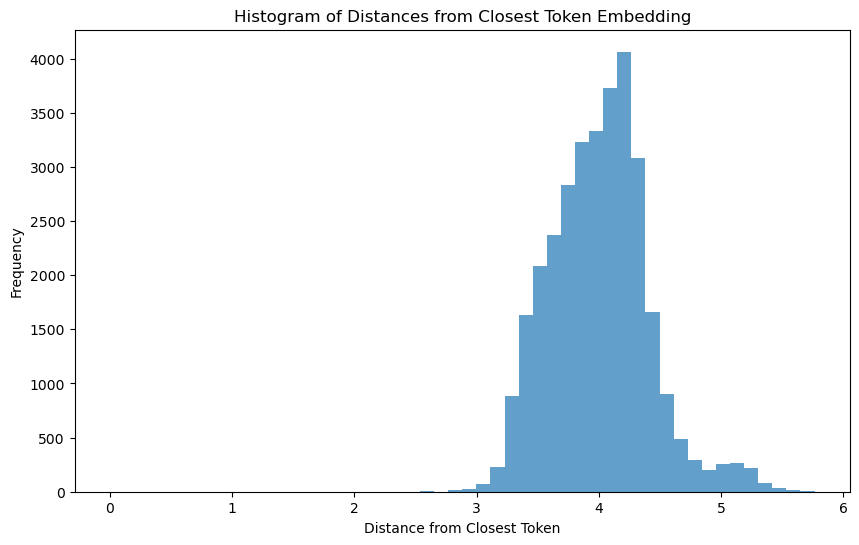

In [15]:
import numpy as np

import matplotlib.pyplot as plt

# Get the embedding for the closest token
closest_embedding = embeddings[closest_idx]

# Calculate Euclidean distances from closest embedding to all other embeddings
distances_from_closest = np.linalg.norm(embeddings - closest_embedding, axis=1)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(distances_from_closest, bins=50, alpha=0.7)
plt.xlabel('Distance from Closest Token')
plt.ylabel('Frequency')
plt.title('Histogram of Distances from Closest Token Embedding')
plt.show()

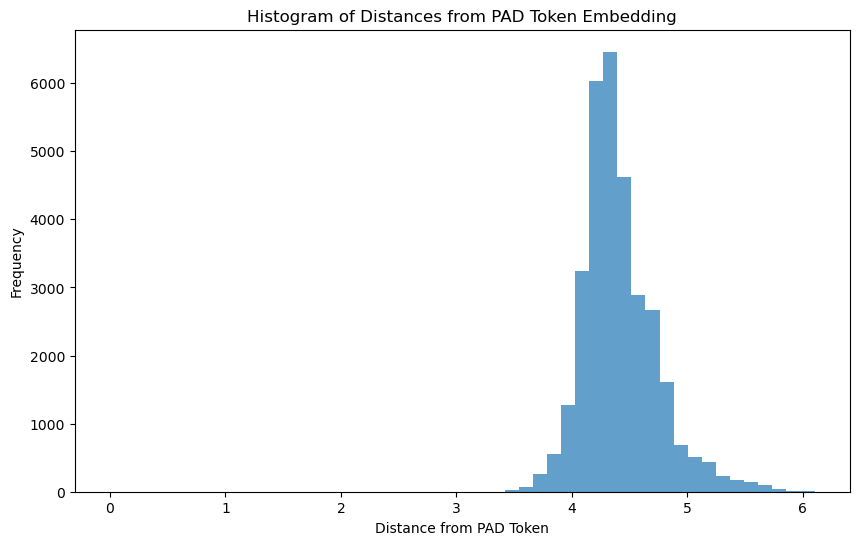

In [16]:
import numpy as np

import matplotlib.pyplot as plt

# Get the embedding for the PAD token (ID 3)
pad_embedding = embeddings[3]

# Calculate Euclidean distances from PAD embedding to all other embeddings
distances_from_pad = np.linalg.norm(embeddings - pad_embedding, axis=1)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(distances_from_pad, bins=50, alpha=0.7)
plt.xlabel('Distance from PAD Token')
plt.ylabel('Frequency')
plt.title('Histogram of Distances from PAD Token Embedding')
plt.show()

Token ATCTCATGCC (ID 23655): Mean distance 4.882595539093018


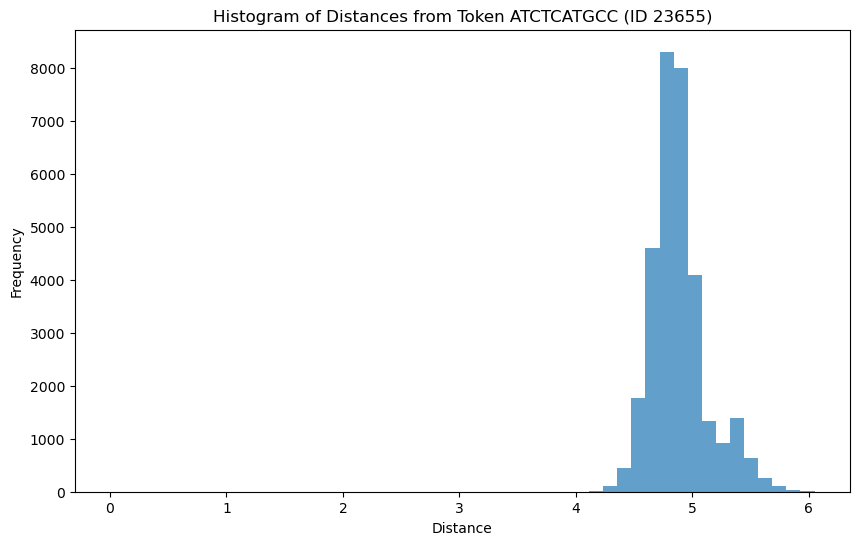

Token AACTAGG (ID 5881): Mean distance 4.2069902420043945


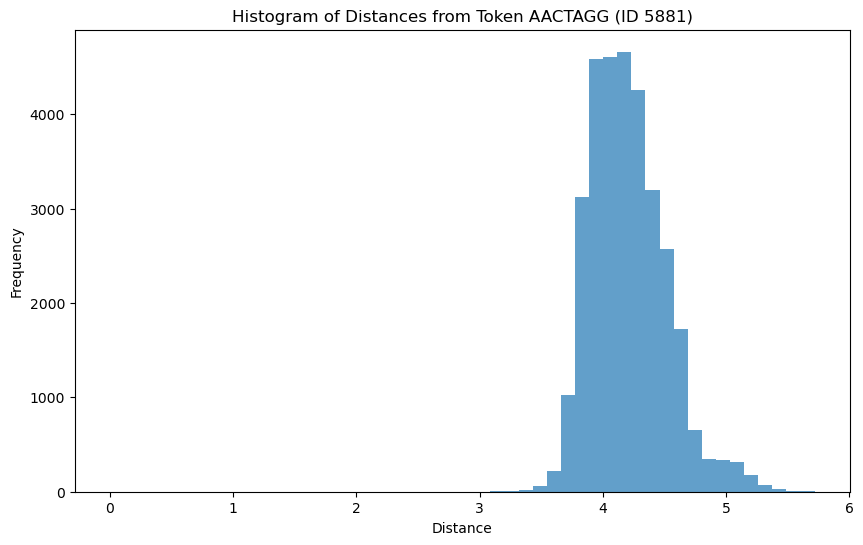

Token TGATATCCCC (ID 15154): Mean distance 4.9877800941467285


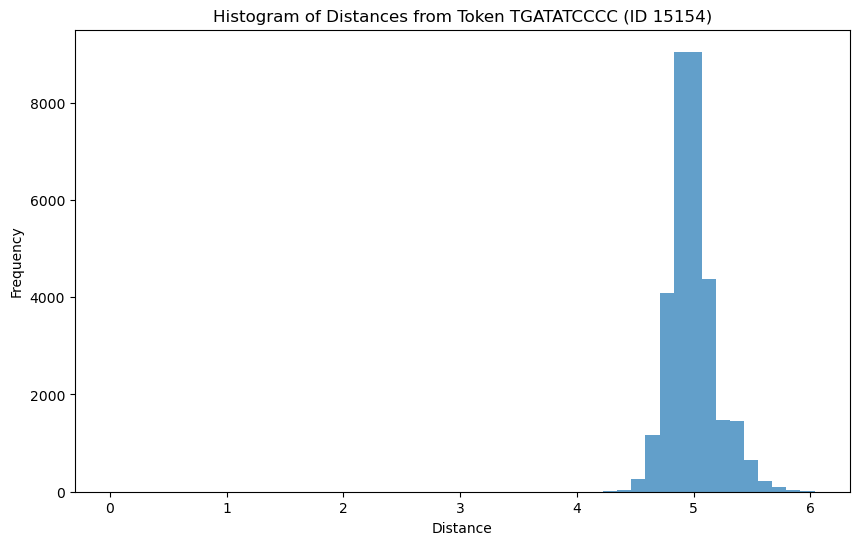

Token TGCTGATG (ID 11570): Mean distance 4.313790798187256


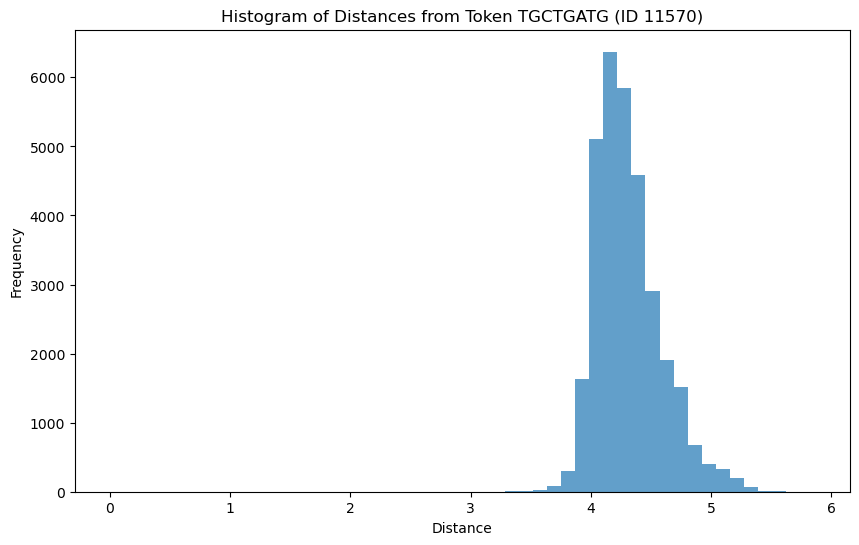

Token AAATTTACC (ID 20285): Mean distance 4.240659236907959


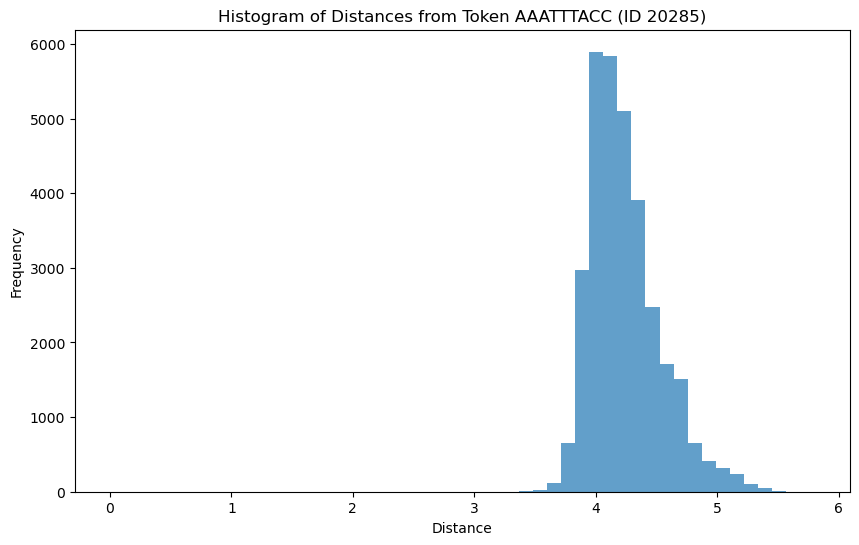

Token TAGCCGG (ID 13936): Mean distance 4.198630332946777


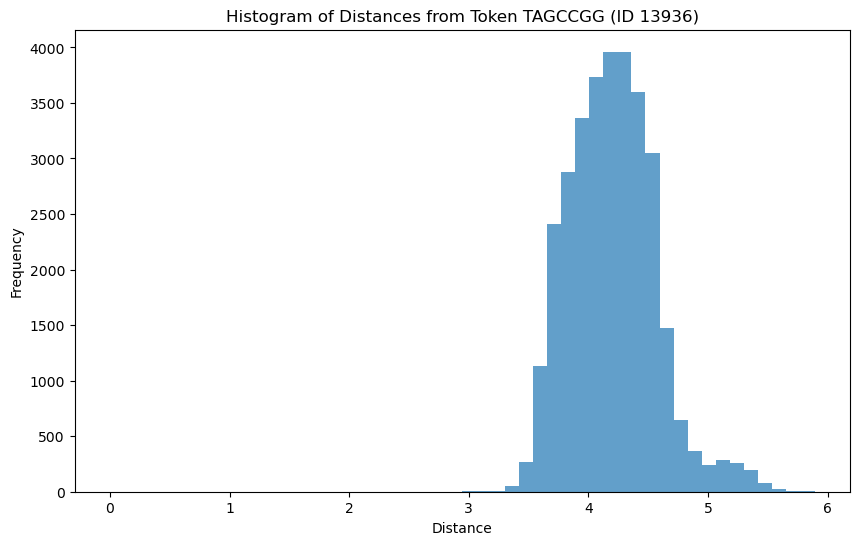

Token TGAGCTCAAG (ID 27960): Mean distance 4.912240982055664


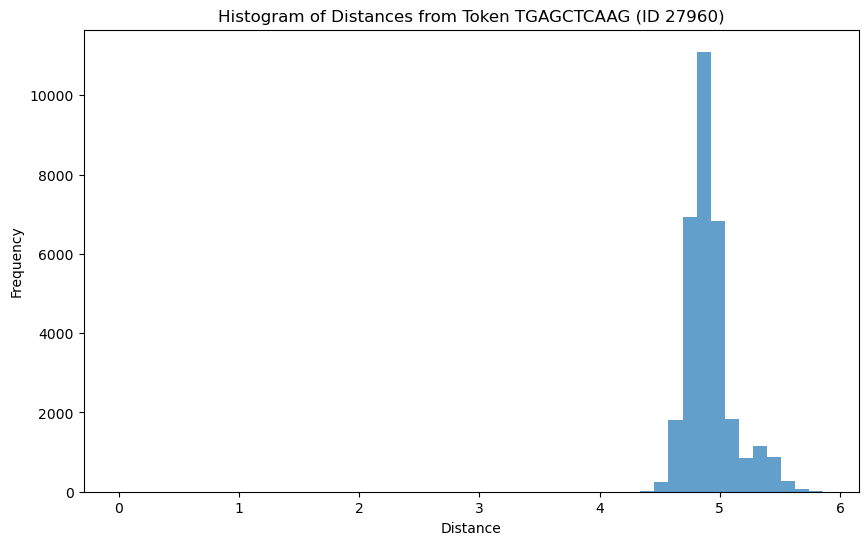

Token AGTGCAGTGGTGTG (ID 16666): Mean distance 4.774259090423584


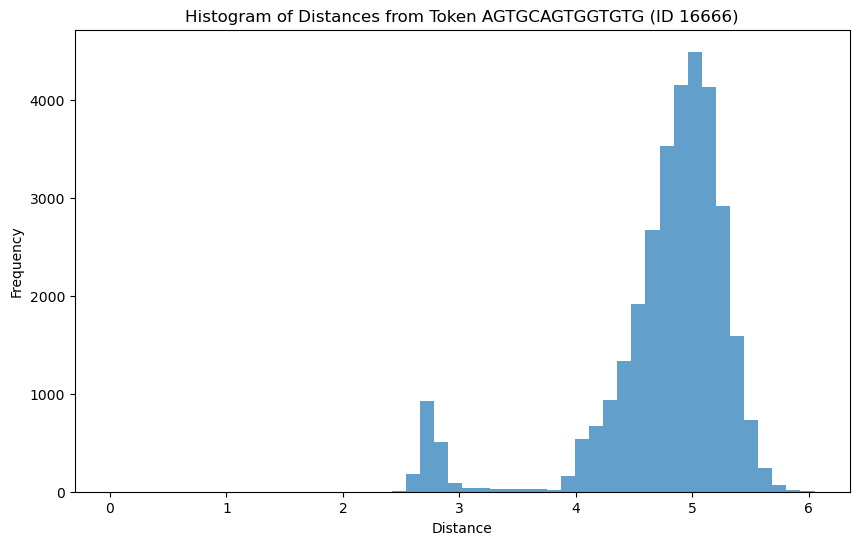

Token TTTTGAGAC (ID 11615): Mean distance 4.389745235443115


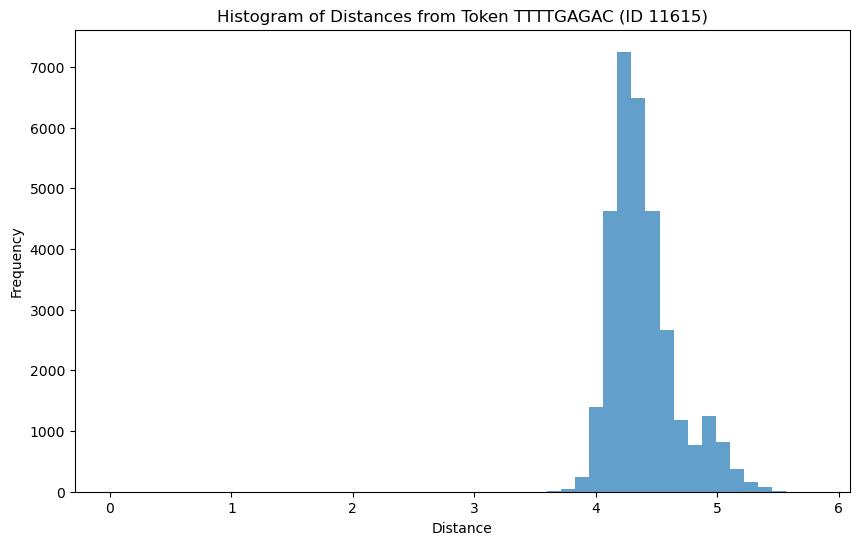

Token ACCTTATG (ID 18000): Mean distance 4.383544921875


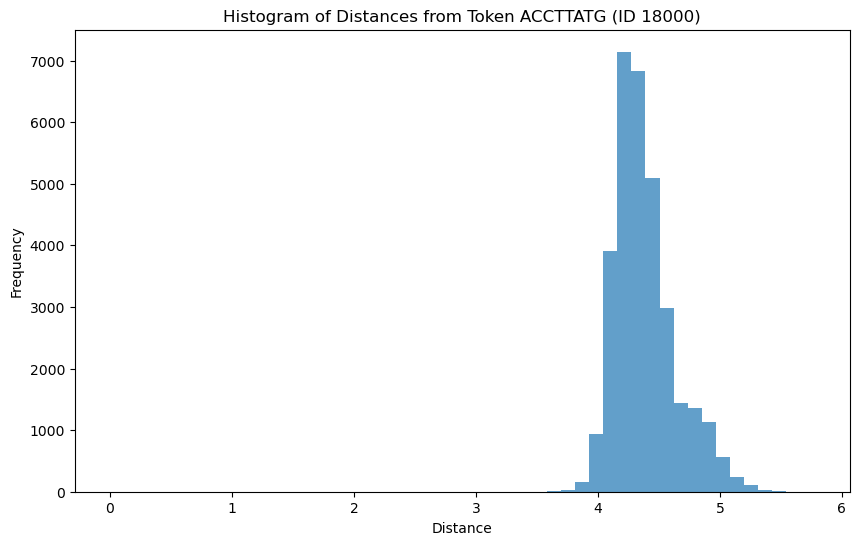

Token TACTATTG (ID 21128): Mean distance 4.442532062530518


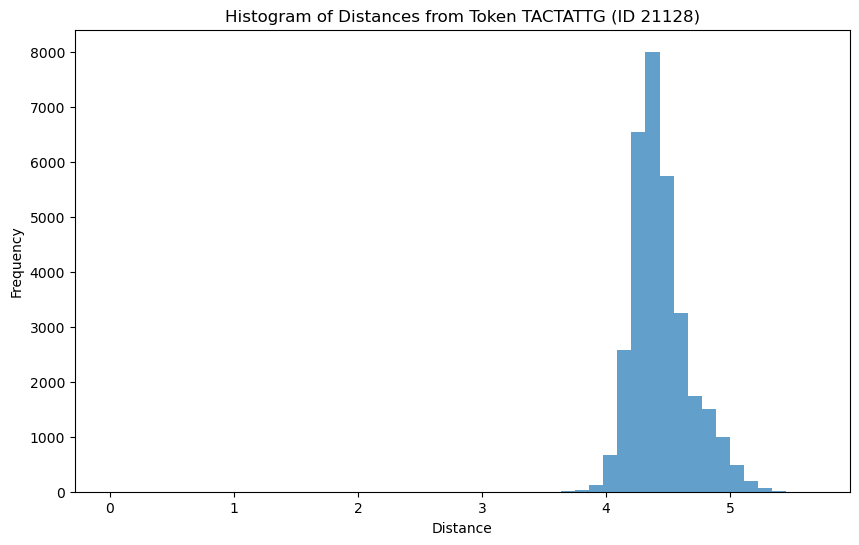

Token AGAGGGGGG (ID 20347): Mean distance 4.362034320831299


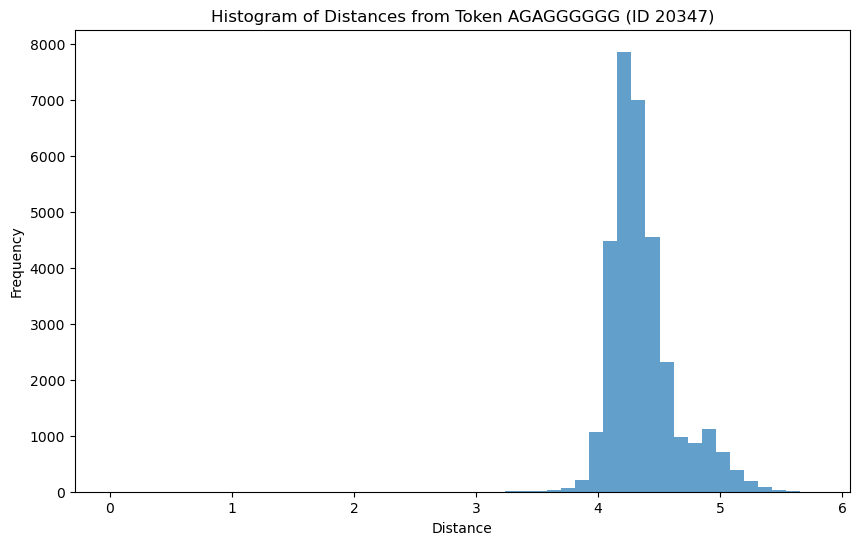

Token TACAGAAC (ID 5074): Mean distance 4.259542942047119


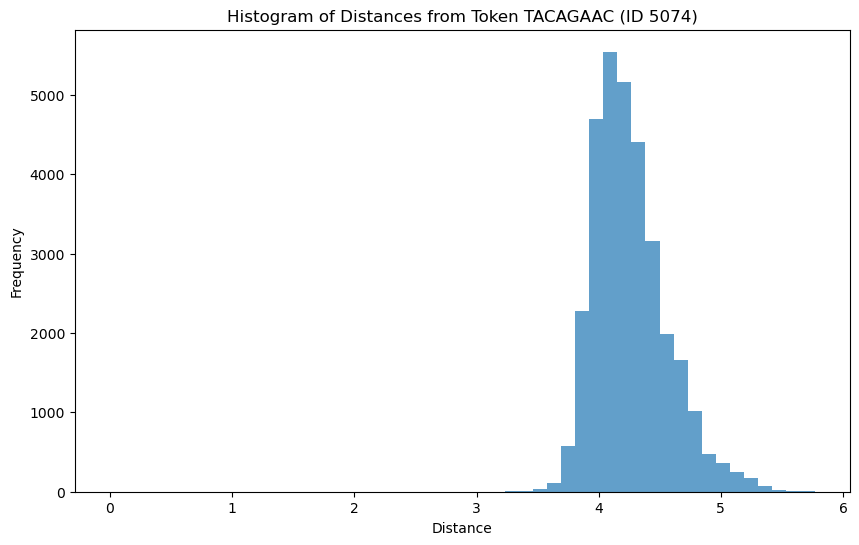

Token GTGTGCATGTGTC (ID 17672): Mean distance 4.975228309631348


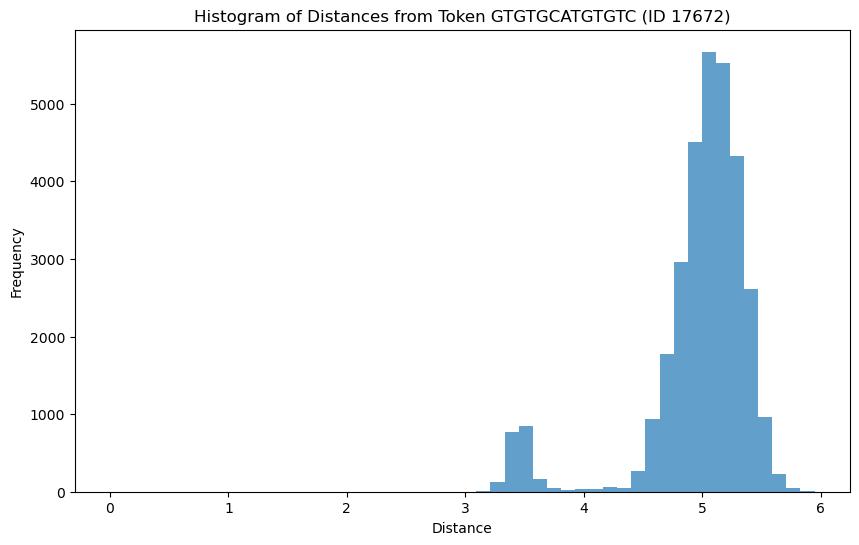

Token TTGGATTG (ID 11590): Mean distance 4.211361408233643


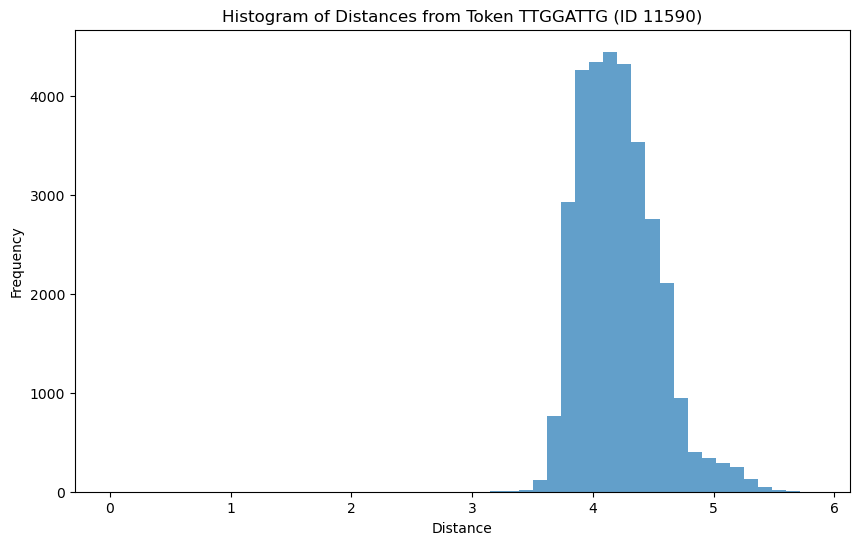

In [17]:
import numpy as np
import random

import matplotlib.pyplot as plt

# Select 15 random token IDs
random_tokens = random.sample(range(len(embeddings)), 15)

for token_id in random_tokens:
    token_embedding = embeddings[token_id]
    distances = np.linalg.norm(embeddings - token_embedding, axis=1)
    mean_distance = np.mean(distances)
    token_str = tokenizer.convert_ids_to_tokens(token_id)
    print(f"Token {token_str} (ID {token_id}): Mean distance {mean_distance}")
    
    plt.figure(figsize=(10, 6))
    plt.hist(distances, bins=50, alpha=0.7)
    plt.xlabel('Distance')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Distances from Token {token_str} (ID {token_id})')
    plt.show()